In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
os.chdir("..")

In [3]:
df_locale = pd.read_csv("results/benchmark_results.csv")
df_locale

,percentuale,motore,analisi,tempo_secondi,status
0,10,Hive,3.1,147,0
1,10,Spark_SQL,3.1,15,0
2,10,Spark_Core,3.1,13,0
3,10,Hive,3.2,471,0
4,10,Spark_SQL,3.2,18,0
5,10,Spark_Core,3.2,16,0
6,10,Hive,3.3,244,0
7,10,Spark_SQL,3.3,14,0
8,10,Spark_Core,3.3,13,0
9,25,Hive,3.1,97,0


In [4]:
df_cluster = pd.read_csv("results_cluster/benchmark_results.csv")
df_cluster

,percentuale,motore,analisi,tempo_secondi,status
0,10,Spark_SQL,3.3,62,0
1,10,Hive,3.1,19,0
2,10,Spark_Core,3.3,27,0
3,10,Spark_SQL,3.1,18,0
4,10,Spark_Core,3.1,21,0
...,...,...,...,...,...
96,150,Spark_SQL,3.2,28,0
97,150,Spark_Core,3.2,22,0
98,150,Hive,3.3,20,0
99,150,Spark_SQL,3.3,16,0


In [5]:
df_cluster = df_cluster.groupby(['percentuale', 'motore', 'analisi'])['tempo_secondi'].sum().reset_index()
df_cluster

,percentuale,motore,analisi,tempo_secondi
0,10,Hive,3.1,19
1,10,Hive,3.2,24
2,10,Hive,3.3,31
3,10,Spark_Core,3.1,21
4,10,Spark_Core,3.2,24
5,10,Spark_Core,3.3,52
6,10,Spark_SQL,3.1,18
7,10,Spark_SQL,3.2,24
8,10,Spark_SQL,3.3,79
9,25,Hive,3.1,40


In [6]:
totali_motore_cluster = df_cluster.groupby('motore')['tempo_secondi'].sum().reset_index()
totali_motore_cluster = totali_motore_cluster.sort_values(by='tempo_secondi')
totali_motore_cluster['tempo'] = pd.to_timedelta(totali_motore_cluster['tempo_secondi'], unit='s').astype(str).map(lambda x: x.split()[-1])
totali_motore_cluster

,motore,tempo_secondi,tempo
1,Spark_Core,778,00:12:58
0,Hive,867,00:14:27
2,Spark_SQL,871,00:14:31


In [7]:
totali_motore_locale = df_locale.groupby('motore')['tempo_secondi'].sum().reset_index()
totali_motore_locale = totali_motore_locale.sort_values(by='tempo_secondi')
totali_motore_locale['tempo'] = pd.to_timedelta(totali_motore_locale['tempo_secondi'], unit='s').astype(str).map(lambda x: x.split()[-1])
totali_motore_locale

,motore,tempo_secondi,tempo
1,Spark_Core,241,00:04:01
2,Spark_SQL,295,00:04:55
0,Hive,4278,01:11:18


In [8]:
sns.set_theme(style="whitegrid")

In [9]:
def grafico(df, testo):
    percentuali = sorted(df['percentuale'].unique())

    for perc in percentuali:
        df_perc = df[df['percentuale'] == perc]
        
        plt.figure(figsize=(10, 6))
        
        ax = sns.barplot(
            data=df_perc, 
            x='analisi', 
            y='tempo_secondi', 
            hue='motore', 
            palette='Set2'
        )
        
        plt.title(f'Confronto tempi {testo}', fontsize=14, pad=15)
        plt.xlabel('Analisi', fontsize=12)
        plt.ylabel('Tempo di esecuzione (s)', fontsize=12)
        
        plt.legend(title='Tecnologia')
        
        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f"{int(p.get_height())}s", 
                            (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='center', 
                            xytext=(0, 9), textcoords='offset points',
                            fontsize=10)
        
        plt.tight_layout()
        plt.show()

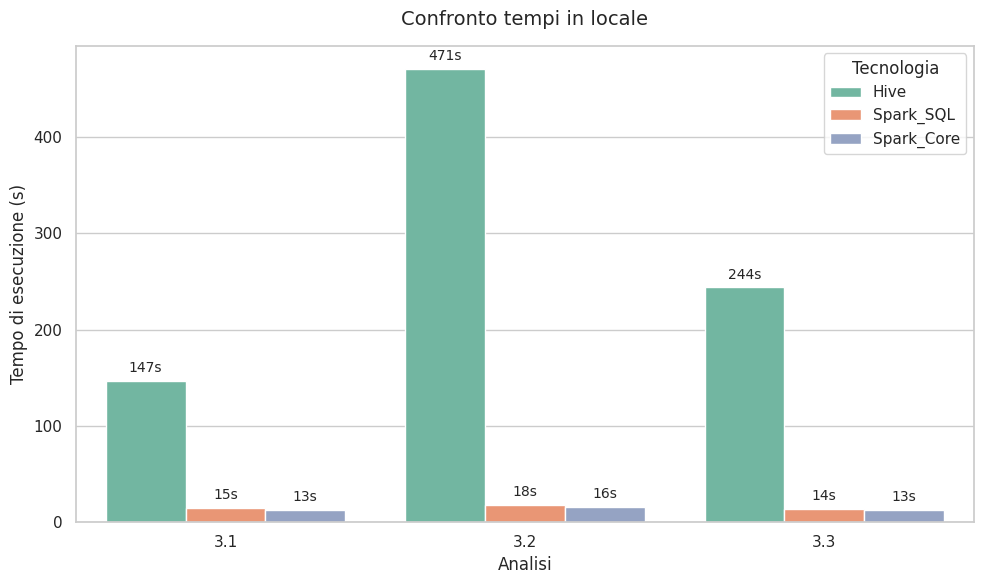

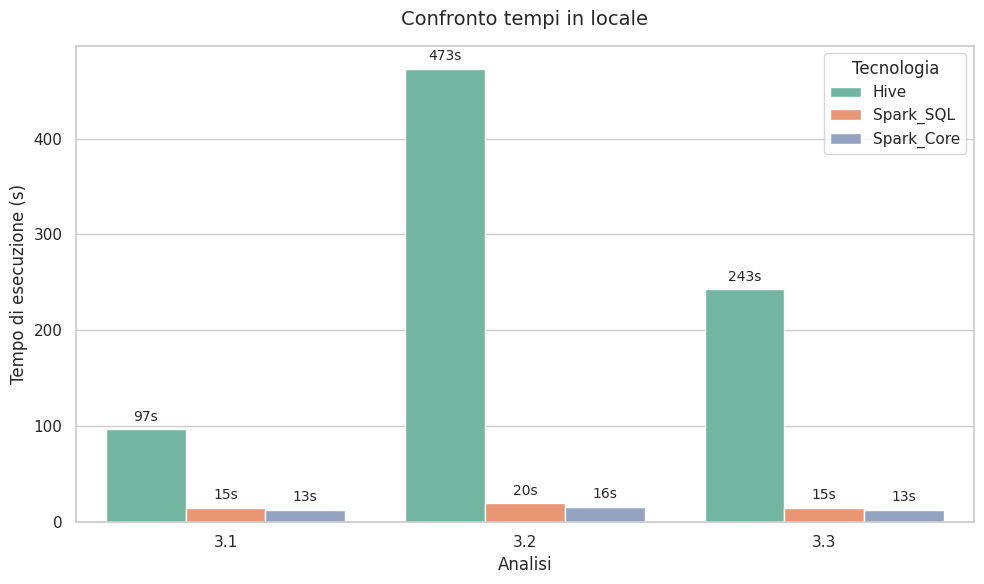

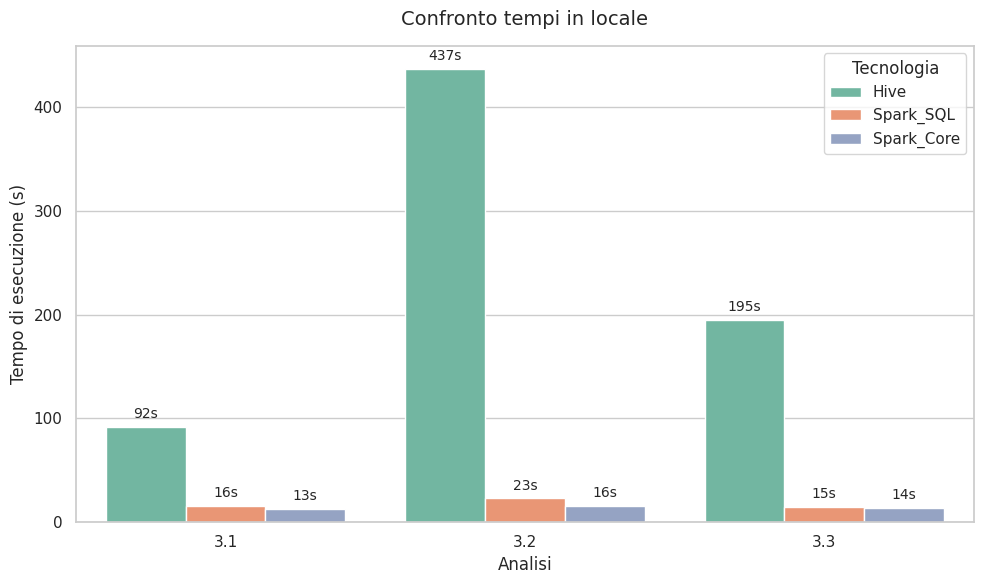

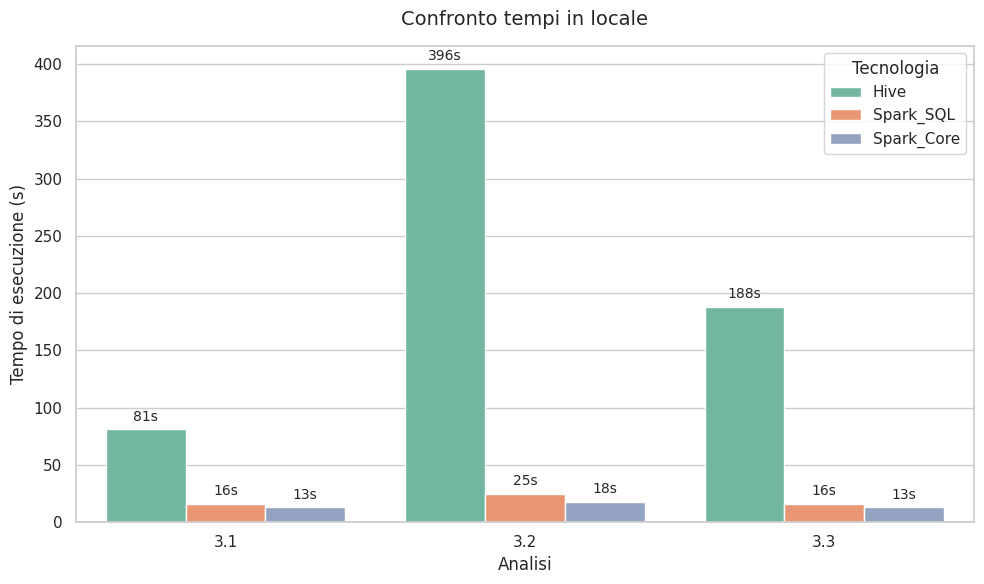

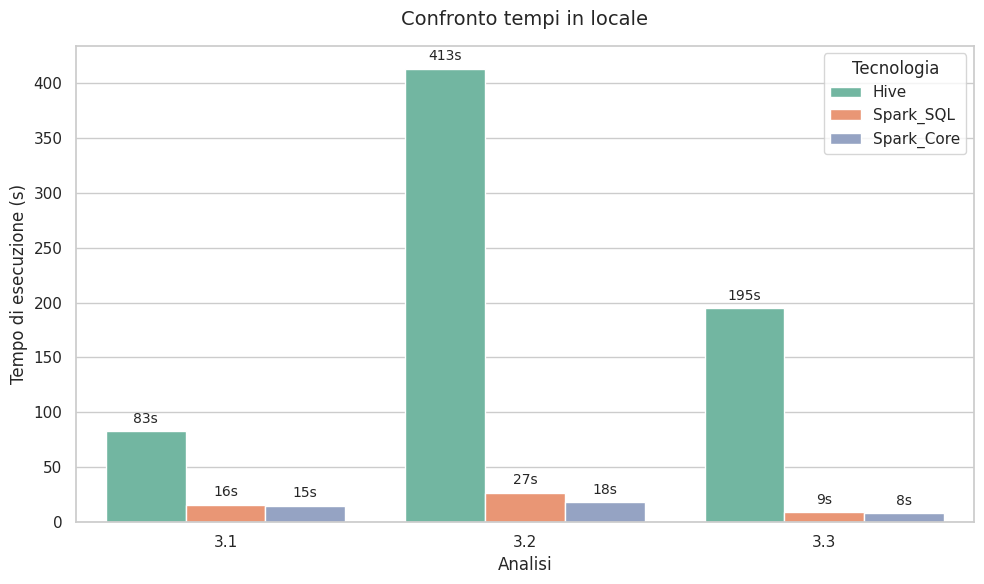

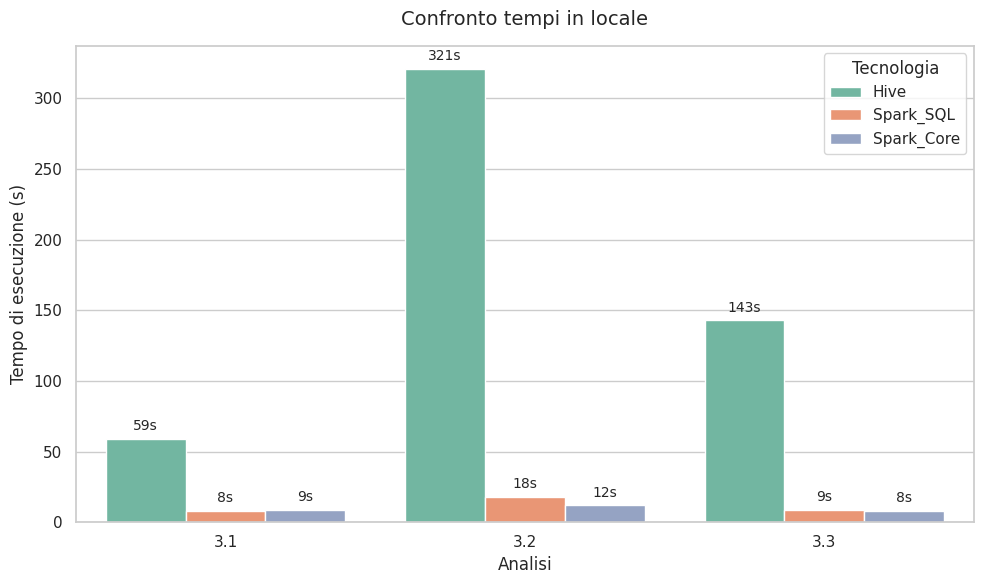

In [10]:
grafico(df_locale, "in locale")

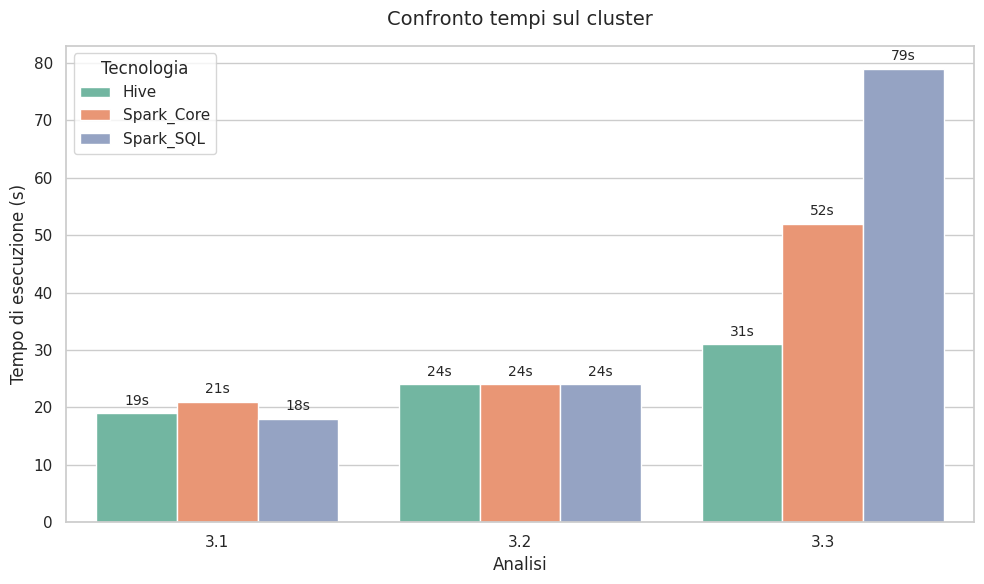

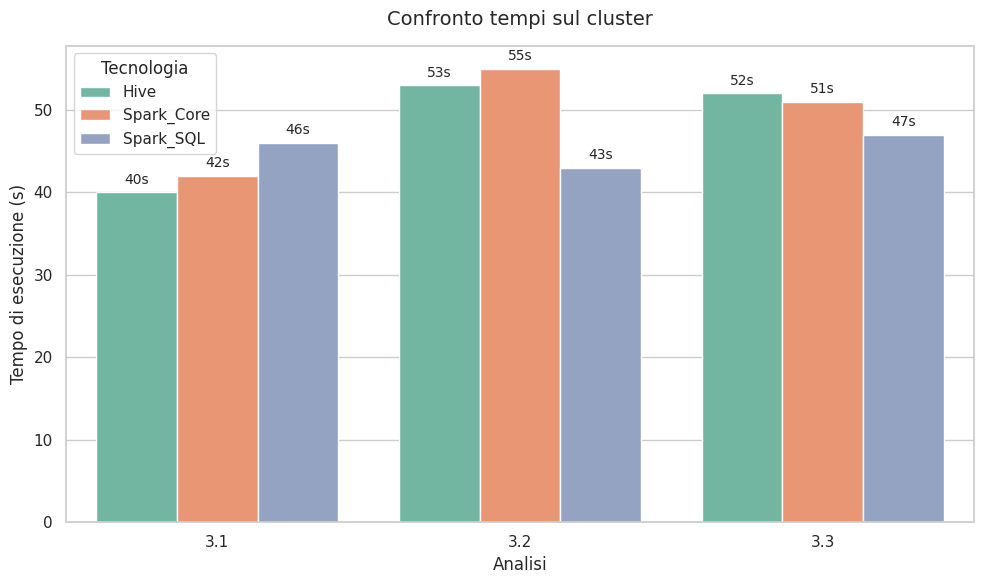

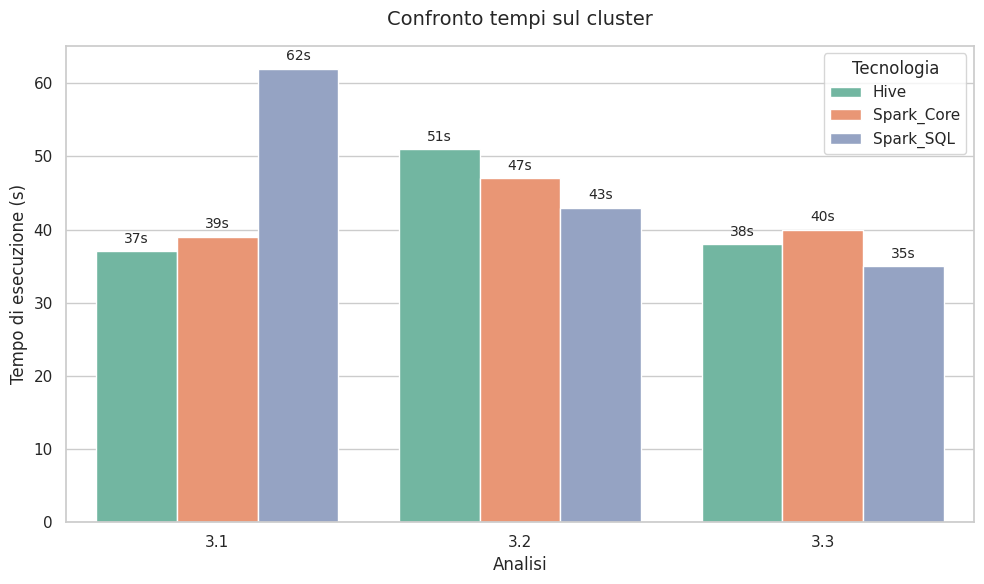

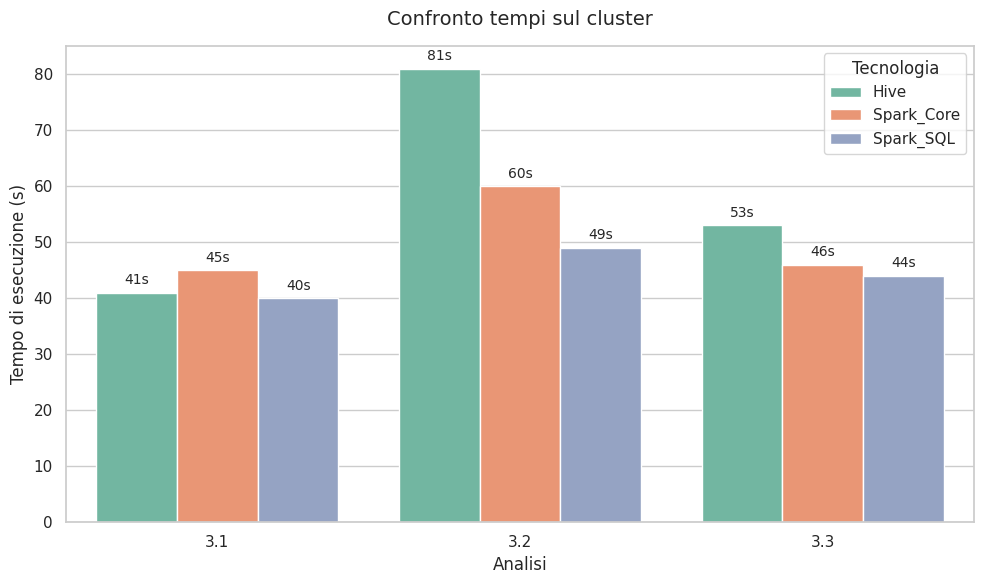

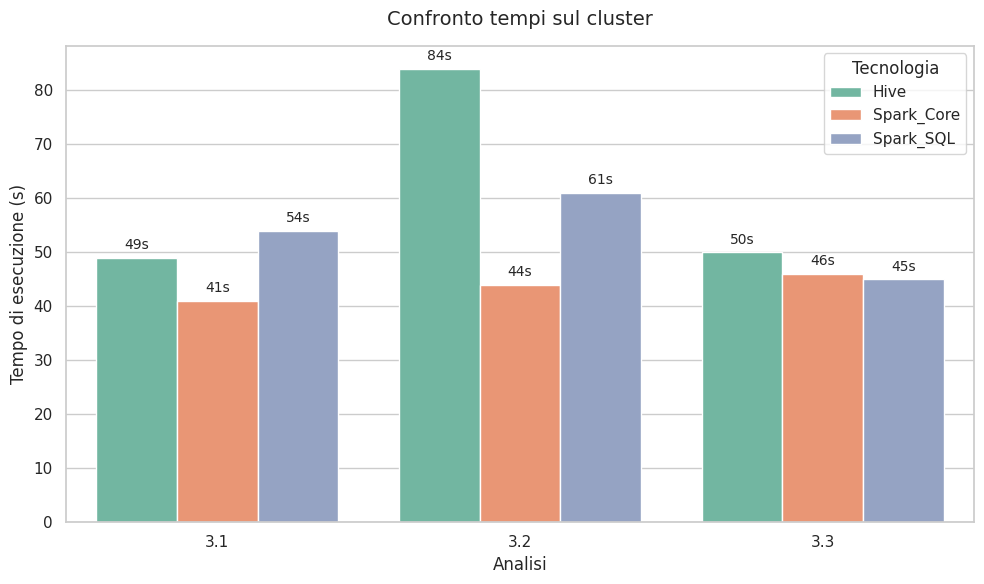

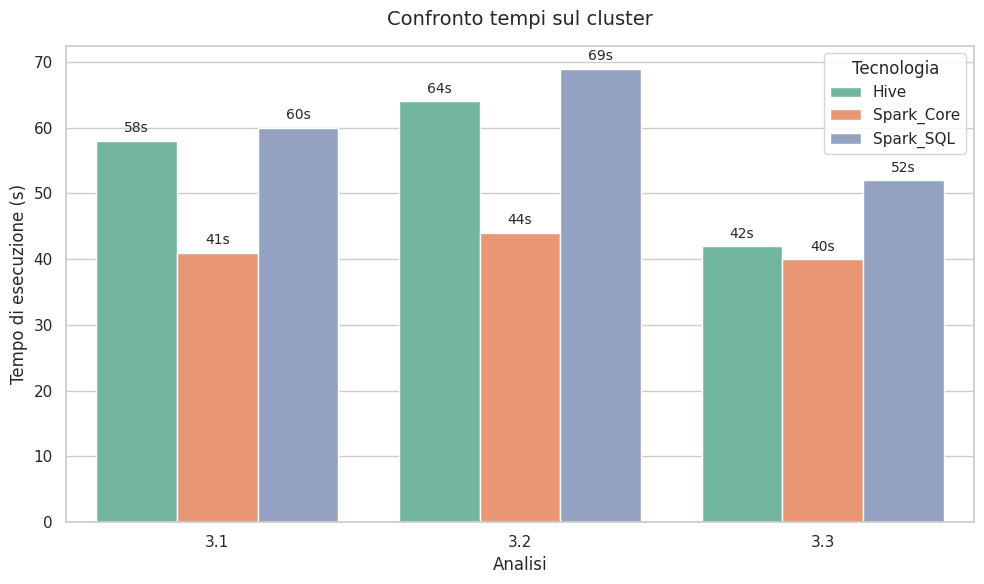

In [13]:
grafico(df_cluster, "sul cluster")

In [14]:
totali_motore_locale['tempo_secondi_locale'] = totali_motore_locale['tempo_secondi']
totali_motore_cluster['tempo_secondi_cluster'] = totali_motore_cluster['tempo_secondi']

df_confronto = pd.merge(totali_motore_locale, totali_motore_cluster, on='motore')

df_melt = df_confronto.melt(
    id_vars=['motore'], 
    value_vars=['tempo_secondi_cluster', 'tempo_secondi_locale'], 
    var_name='Ambiente', 
    value_name='Tempo (Secondi)'
)

df_melt['Ambiente'] = df_melt['Ambiente'].replace({
    'tempo_secondi_cluster': 'Cluster', 
    'tempo_secondi_locale': 'Locale'
})
df_melt

,motore,Ambiente,Tempo (Secondi)
0,Spark_Core,Cluster,778
1,Spark_SQL,Cluster,871
2,Hive,Cluster,867
3,Spark_Core,Locale,241
4,Spark_SQL,Locale,295
5,Hive,Locale,4278


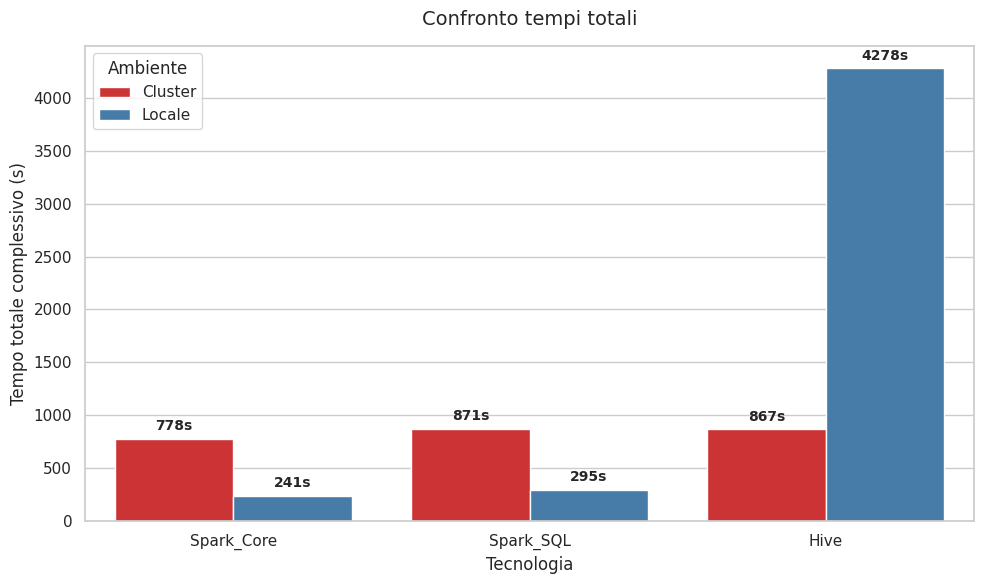

In [16]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_melt, 
    x='motore', 
    y='Tempo (Secondi)', 
    hue='Ambiente', 
    palette='Set1'
)

plt.title('Confronto tempi totali', fontsize=14, pad=15)
plt.xlabel('Tecnologia', fontsize=12)
plt.ylabel('Tempo totale complessivo (s)', fontsize=12)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height())}s", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()